## Dataset Analysis
Perform analysis on distribution of traffic, types of attacks present, and infer the possible variables that may be the factor for attack patterns.

In [4]:
!pip install -r requirements.txt

In [5]:
from scipy.io import arff
import pandas as pd

# to avoid base 10 exponents
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

arff_file = arff.loadarff("dataset/KDDTrain+.arff")
train_dataset_df = pd.DataFrame(arff_file[0])

# decode the bytes loaded from scipy (default behavior)
categorical_cols = train_dataset_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    try:
        train_dataset_df[col] = train_dataset_df[col].str.decode('utf-8')

    # exception triggers when the column is already a string
    except AttributeError:
        continue

# normalize the integer columns from float64 -> integer
numeric_real_cols = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "land",
    "logged_in",
    "is_host_login",
    "is_guest_login"
]

for numeric_columns in numeric_real_cols:
    train_dataset_df[numeric_columns] = pd.to_numeric(train_dataset_df[numeric_columns])


In [6]:
train_dataset_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0.000,tcp,ftp_data,SF,491.000,0.000,0,0.000,0.000,0.000,...,25.000,0.170,0.030,0.170,0.000,0.000,0.000,0.050,0.000,normal
1,0.000,udp,other,SF,146.000,0.000,0,0.000,0.000,0.000,...,1.000,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal
2,0.000,tcp,private,S0,0.000,0.000,0,0.000,0.000,0.000,...,26.000,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,anomaly
3,0.000,tcp,http,SF,232.000,8153.000,0,0.000,0.000,0.000,...,255.000,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal
4,0.000,tcp,http,SF,199.000,420.000,0,0.000,0.000,0.000,...,255.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal


In [7]:
train_dataset_df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='str')

In [8]:
train_dataset_df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.000,287.145,2604.515,0.000,0.000,0.000,0.000,42908.000
src_bytes,125973.000,45566.743,5870331.182,0.000,0.000,44.000,276.000,1379963888.000
dst_bytes,125973.000,19779.114,4021269.151,0.000,0.000,0.000,516.000,1309937401.000
land,125973.000,0.000,0.014,0.000,0.000,0.000,0.000,1.000
wrong_fragment,125973.000,0.023,0.254,0.000,0.000,0.000,0.000,3.000
urgent,125973.000,0.000,0.014,0.000,0.000,0.000,0.000,3.000
hot,125973.000,0.204,2.150,0.000,0.000,0.000,0.000,77.000
num_failed_logins,125973.000,0.001,0.045,0.000,0.000,0.000,0.000,5.000
logged_in,125973.000,0.396,0.489,0.000,0.000,0.000,1.000,1.000
num_compromised,125973.000,0.279,23.942,0.000,0.000,0.000,0.000,7479.000


In [9]:
train_dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  float64
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  float64
 5   dst_bytes                    125973 non-null  float64
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  float64
 8   urgent                       125973 non-null  float64
 9   hot                          125973 non-null  float64
 10  num_failed_logins            125973 non-null  float64
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  float64
 13  root_shell

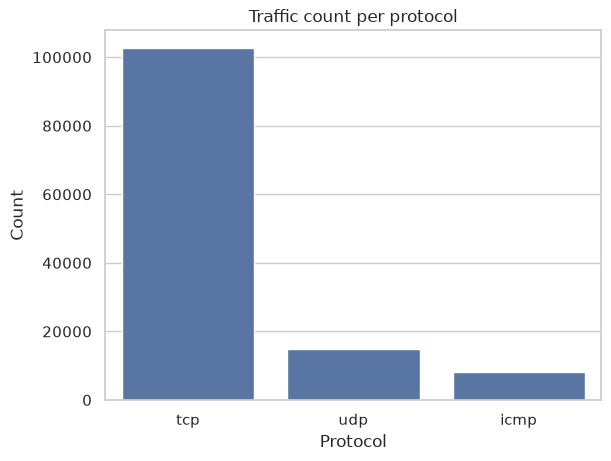

In [10]:
import seaborn as sn
import matplotlib.pyplot as plt

# show all the protocols available from the dataset
protocols = train_dataset_df["protocol_type"].unique()
plot_data = {
    "Protocol": list(protocols),
    "Count": []
}

for protocol in protocols:
    protocol_count = (train_dataset_df["protocol_type"] == protocol).sum()
    plot_data["Count"].append(protocol_count)

# load a dataframe for the plot data
df = pd.DataFrame(plot_data)

sn.set_theme(style="whitegrid")
sn.barplot(df, x="Protocol", y="Count")

plt.title("Traffic count per protocol")
plt.show()

In [11]:
# checking for any rows with null values
train_dataset_df[train_dataset_df.isna().any(axis=1)]


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class


no null values for each of the row (probably no corrupted), but we still have to deal with outlier data

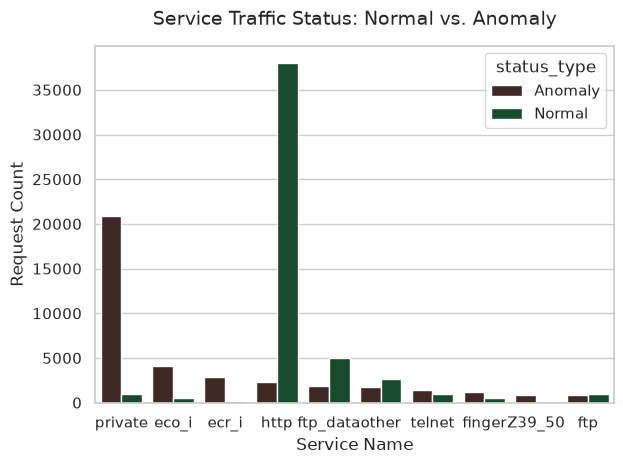

In [39]:
service_activity_count = pd.crosstab(
    train_dataset_df["service"],
    train_dataset_df["class"],
    margins_name="total_count",
    margins=True,
)

# reset the index to fix the table format 
df_counts = service_activity_count.drop('total_count', axis=0)
df_counts = df_counts.rename(columns={
    'anomaly': 'anomaly_count',
    'normal': 'normal_count'
}).reset_index()


# for getting the top 10 most used service as reference for anomaly checking (can correlate this)
top_10_anomalous_service = df_counts.sort_values(by="anomaly_count", ascending=False).head(10)
top_10_anomalous_order = top_10_anomalous_service["service"].copy().to_list()

top_10_anomalous_service = df_counts[df_counts["service"].isin(top_10_anomalous_service["service"])]

# format to df_long for seaborn to interpret
df_long = pd.melt(
    top_10_anomalous_service, 
    id_vars=["service"], 
    value_vars=["anomaly_count", "normal_count"],
    var_name="status_type", 
    value_name="count"
)

# just for name consistency
df_long['status_type'] = df_long['status_type'].str.replace('_count', '').str.title()

ax = sn.barplot(
    data=df_long,
    x='service',
    y='count',
    hue='status_type',
    order=top_10_anomalous_order,
    palette=["#442420", "#10532c"]
)

ax.set_title('Service Traffic Status: Normal vs. Anomaly', fontsize=14, pad=15)
ax.set_xlabel('Service Name', fontsize=12)
ax.set_ylabel('Request Count', fontsize=12)

plt.tight_layout()
plt.show()

It can be seen here that the `private` service has the highest anomalous packet count, and although `http` packet has one of the highest total packet count, it is not as targeted as `private`, `eco` and `ecr` services, which may indicate something (like, does the network has some sort of weakness over these service?)